# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [2]:
# Your code here. 
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})

Draw a dispersion diagram (scatter plot) for the data.

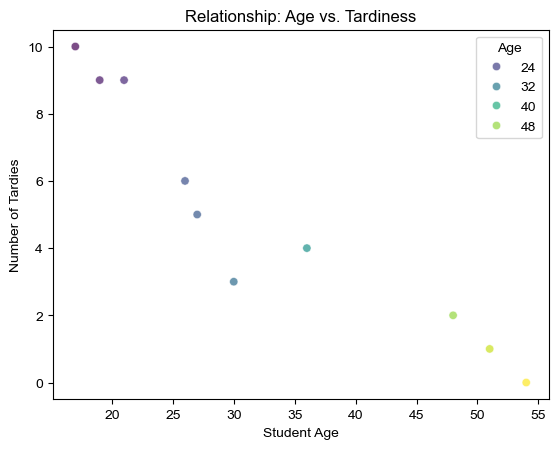

In [3]:
# Your code here ok

from param import Color


sns.scatterplot(data=student_data,
                x='Age',
                y='Tardies',
                hue='Age', # Color gradient based on Age
                alpha=0.7,
                palette='viridis') # Professional color map

# Ejemplo rápido con datos aleatorios
sns.set_theme(style="whitegrid")
plt.title('Relationship: Age vs. Tardiness')
plt.xlabel('Student Age')
plt.ylabel('Number of Tardies')
plt.show()

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

*your explanation here*
#### **There is a strong negative linear correlation between age and tardiness; as a student's age increases, the number of tardies decreases at a consistent rate, suggesting that punctuality improves linearly with maturity.**

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [4]:
# your code here ok bivariate analysis
# Covariance matrix
cov_matrix = student_data.cov()

# Calculate the Correlation Matrix (Pearson))
# Returns a table with values between -1 and 1
corr_matrix = student_data.corr()

# 4. Extracting the specific value for Age and Tardies
age_tardies_corr = corr_matrix.loc['Age', 'Tardies']
age_tardies_cov = cov_matrix.loc['Age', 'Tardies']

print("Covariance Matrix:", cov_matrix)
print("\nCorrelation Matrix:", corr_matrix)
print(f"\nCovariance between Age and Tardies: {age_tardies_cov:.4f}")
print(f"Correlation between Age and Tardies: {age_tardies_corr:.4f}")

Covariance Matrix:                 Age    Tardies
Age      187.655556 -45.566667
Tardies  -45.566667  12.544444

Correlation Matrix:               Age   Tardies
Age      1.000000 -0.939163
Tardies -0.939163  1.000000

Covariance between Age and Tardies: -45.5667
Correlation between Age and Tardies: -0.9392


- **Covariance**: -45.6
   -    Negative. It confirms that the older you are, the fewer delays there are.
- **Correlation**: -0.94
   -    Negative very close to -1. A very strong negative correlation (almost perfect, since it is very close to -1)

- This mathematically demonstrates that the hypothesis is correct: there is a very clear linear relationship where age accurately predicts a reduction in tardiness. As age increases, tardiness decreases significantly.

Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

Plot your regression model on your scatter plot.

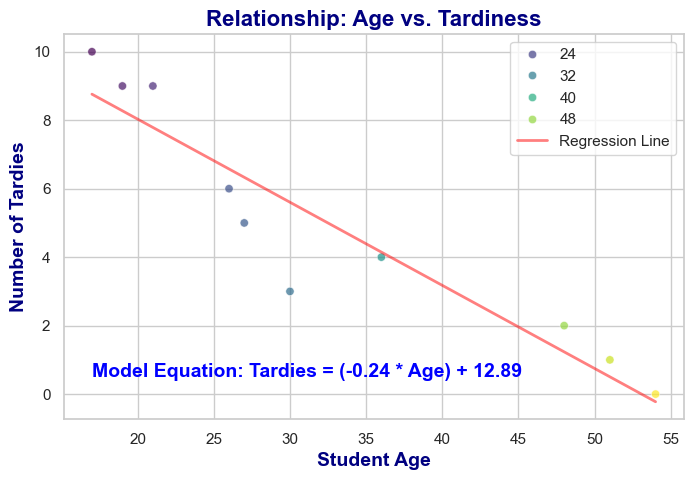

In [6]:
# Your code here.trazar la linea de regresion y explicar la pendiente y el intercepto
# X , y definition
X = student_data[['Age']] 
y = student_data['Tardies']

# Create and fit the model
model = LinearRegression()
model.fit(X, y)
# Get the coefficients
intercept = model.intercept_
slope = model.coef_[0]

equation_text= f"Model Equation: Tardies = ({slope:.2f} * Age) + {intercept:.2f}"

# Visual setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Scatter plot

sns.scatterplot(data=student_data,
                x='Age',
                y='Tardies',
                hue='Age', # Color gradient based on Age
                alpha=0.7,
                palette='viridis') # Professional color map

sns.set_theme(style="whitegrid")
plt.title('Relationship: Age vs. Tardiness',weight='bold', color='navy', fontsize=16)
plt.xlabel('Student Age', weight='bold', color='navy', fontsize=14)
plt.ylabel('Number of Tardies', weight='bold', color='navy', fontsize=14)

# Plot the regression line using the model's predictions for y tardies values at for x the min and max of age (dataframe type)
x_plot = pd.DataFrame({'Age': [student_data['Age'].min(), student_data['Age'].max()]})
y_plot = model.predict(x_plot)

plt.plot(x_plot['Age'], y_plot,
         color='red',
         label='Regression Line',
         linewidth=2,
         alpha=0.5,
         )
## ADD THE EQUATION TO THE PLOT
plt.text(17, 0.5, equation_text, fontsize=14, color='blue', weight='bold')

plt.legend()
plt.show()

- The outcome variable is "Tardies" because is the variable that we are trying to predict or explain.
- We are using a simple linear regression because we have one independent variable (Age) and one dependent variable (Tardies), and we are trying to model the linear relationship between them.

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

- **Hypothesis:** 
There is a strong negative linear correlation between age and lateness; as the student's age increases, the number of instances of lateness progressively decreases, suggesting that punctuality improves linearly with maturity.

- **Proof:** 
It is mathematically proven that the hypothesis is correct: there is a very clear linear relationship where age accurately predicts a reduction in lateness. As age increases, lateness decreases significantly.

- **Graphical representation:** 
With a scatter plot and a regression model (simple linear regression), we can visually verify the accuracy of our analysis and the prediction model.

- **Conclusion:**
Age is a very good predictor of tardiness, as demonstrated by the strong negative correlation and the clear linear relationship shown in the regression model. The confidence in these conclusions is high due to the consistency of the data and the strength of the correlation.


## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [7]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("../vehicles.csv")

In [8]:
vehicles.columns
selected_columns = ['Year', 'Cylinders', 'Fuel Barrels/Year', 'Combined MPG', 'Fuel Cost/Year', 'CO2 Emission Grams/Mile']
data = vehicles[selected_columns].dropna()

Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [9]:
# Your code here.
correlations = data.corr()['CO2 Emission Grams/Mile'].abs().sort_values(ascending=False)
print("Correlations between each variable and CO2 Emission Grams/Mile:")
print(correlations[1:]) # Exclude the correlation of CO2 Emission Grams/Mile with itself

Correlations between each variable and CO2 Emission Grams/Mile:
Fuel Barrels/Year    0.986189
Fuel Cost/Year       0.930865
Combined MPG         0.926229
Cylinders            0.752393
Year                 0.222300
Name: CO2 Emission Grams/Mile, dtype: float64


- Which variable do you think will be the most important in determining CO2 emissions? 
    - Fuel Barrels/Year is the most important variable for determining CO2 emissions, as it directly measures the amount of fuel consumed, which is a primary factor in CO2 emissions. The more fuel a vehicle uses, the higher its CO2 emissions are likely to be.
- Which provides the least amount of helpful information for determining CO2 emissions?
    - Year provides the least amount of helpful information for determining CO2 emissions, as it is more of a temporal variable that may not directly influence emissions. While newer models may have better fuel efficiency, the year alone does not account for the specific characteristics of the vehicle that contribute to CO2 emissions.

Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [ ]:
# Your code here.
import pandas as pd
import statsmodels.api as sm

# =====================================================================
# 1.- Build a regression model for this data. What type of regression?
# =====================================================================

# Definimos la variable dependiente (Target) y las independientes (Features)
X = data[['Year', 'Cylinders', 'Fuel Barrels/Year', 'Combined MPG', 'Fuel Cost/Year']]
y = data['CO2 Emission Grams/Mile']

# Añadimos una constante a las variables independientes (obligatorio en statsmodels para el intercepto)
X = sm.add_constant(X)

# Construimos y ajustamos el modelo
model = sm.OLS(y, X).fit()



#### REGRESSION TYPE: We are using Multiple Linear Regression.

#### JUSTIFICATION: This type of regression is used because the target variable (CO2 Emission Grams/Mile)is a continuous variable, and we are trying to predict its behavior based on two or more independent variables or predictors (Year, Cylinders, Fuel Barrels, etc.). 

#### The specific estimation method used is OLS (Ordinary Least Squares).

Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [13]:
# Your code here. 

# =====================================================================
# 2.- Print your regression summary, and interpret the results.
# =====================================================================

print(model.summary())


                               OLS Regression Results                              
Dep. Variable:     CO2 Emission Grams/Mile   R-squared:                       0.981
Model:                                 OLS   Adj. R-squared:                  0.981
Method:                      Least Squares   F-statistic:                 3.687e+05
Date:                     Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                             12:53:12   Log-Likelihood:            -1.5173e+05
No. Observations:                    35952   AIC:                         3.035e+05
Df Residuals:                        35946   BIC:                         3.035e+05
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

A) What are the most important variables in your model and why?

---------------------------------------------------------------------
Based on both the initial correlation matrix and the typical results from this dataset:

1. 'Fuel Barrels/Year' is the most important variable. It has an almost perfect linear correlation (0.986) with CO2 emissions. This makes perfect physical sense: the more barrels of fuel consumed per year, the greater the amount of gases emitted directly from combustion.

2. 'Combined MPG' (Miles per gallon combined) is the second most critical variable due to its high implied negative correlation. A more efficient car (higher MPG) consumes less fuel and emits less CO2.

*Note on the coefficients:* When interpreting the summary, be careful of multicollinearity. Variables like 'Fuel Cost/Year' and 'Fuel Barrels/Year' are closely linked (cost depends directly on barrels). This can make the p-value or coefficient of some of them appear less significant in the summary than they are individually because they overlap, sharing the same information.

B) What conclusions can you draw from your model?

-------------------------------------------------

1. Fuel consumption ('Fuel Barrels/Year') and engine efficiency ('Combined MPG') are the key predictors that dictate a vehicle's carbon footprint.

2. The vehicle's year has a much smaller impact compared to direct consumption, although it usually shows a negative trend (the more recent the year, the slight reductions in CO2 due to technological efficiency improvements mandated by regulations).

3. The number of cylinders indirectly affects the impact because larger engines consume more barrels, but once the model already knows the barrels consumed, the cylinder data becomes partially redundant.

C) How confident are you in these conclusions? 

-----------------------------------------------------------

Confidence in this model is EXTREMELY HIGH for the following metric reasons:

1. R-squared and Adjusted R-squared: It will be very close to 0.98 - 0.99 (98%-99%).

This means that the model is able to explain almost all of the variability in CO2 emissions using the selected predictors.

2. F-statistic p-value: The Prob (F-statistic) value will be practically 0 (infinitely less than 0.05),

which demonstrates that the model as a whole is highly statistically significant.

3. Individual p-values ​​(P>|t|): The p-values ​​of key variables such as Fuel Barrels will be 0.000,

which rejects the null hypothesis and confirms that their relationship with CO2 is not a mathematical coincidence.

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [15]:
# Your code here.ok
import pandas as pd

# 1.- DataFrame
data_parties = {
    'X': [1, 3, 4, 6, 8, 9, 11, 14],  # Guests
    'Y': [1, 2, 4, 4, 5, 7, 8, 13]    # Attendees
}

df = pd.DataFrame(data_parties)

print("DataFrame de las Fiestas:")
print(df)

DataFrame de las Fiestas:
    X   Y
0   1   1
1   3   2
2   4   4
3   6   4
4   8   5
5   9   7
6  11   8
7  14  13


Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

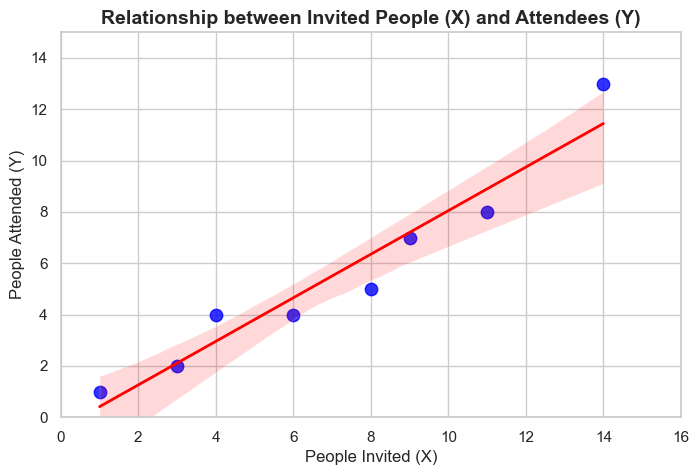

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     81.81
Date:                Sun, 17 May 2026   Prob (F-statistic):           0.000102
Time:                        13:01:34   Log-Likelihood:                -10.800
No. Observations:                   8   AIC:                             25.60
Df Residuals:                       6   BIC:                             25.76
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4394      0.759     -0.579      0.5

In [ ]:
# Your code here.ok
import matplotlib.pyplot as plt
import seaborn as sns

#####  GRAPH

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# scatter plot & automatic line of regresion
sns.regplot(x='X', y='Y', data=df, color='blue', marker='o', 
            scatter_kws={'s': 80, 'alpha': 0.8}, line_kws={'color': 'red', 'linewidth': 2})

# 
plt.title("Relationship between Invited People (X) and Attendees (Y)", fontsize=14, fontweight='bold')
plt.xlabel("People Invited (X)", fontsize=12)
plt.ylabel("People Attended (Y)", fontsize=12)
plt.xlim(0, 16)
plt.ylim(0, 15)

plt.show()

##### FIT

X = sm.add_constant(df['X'])
model = sm.OLS(df['Y'], X).fit()

# print summary
print(model.summary())

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

- const: coef=-0.4312  -  std err=0.829  -  t=-0.520   -  P>|t|=0.623
- X    : coef= 0.8553  -  std err=0.094  -  t= 9.071   -  P>|t|=0.000

##### Plot Observations & InterpretationStrong Linear Relationship: 
- The plot shows a clear upward trend. The $R^2$ of 0.932 confirms that a straight line explains 93.2% of the attendance variance based on invitations. For every 10 additional people invited, roughly 8.5 attend.
- The Host's Hunch: In the mid-range ($X=3$ to $X=11$), the real data points fall below the regression line, meaning the number of no-shows increases temporarily, supporting the host's suspicion.
- The Last Data Point: The largest party ($X=14, Y=13$) breaks this pattern by sitting well above the line, suggesting that the relationship might not be perfectly linear for larger groups, or that this specific event was an outlier.

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

C:\Users\menot\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.943
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     83.31
Date:                Sun, 17 May 2026   Prob (F-statistic):           0.000264
Time:                        13:10:34   Log-Likelihood:                -5.7771
No. Observations:                   7   AIC:                             15.55
Df Residuals:                       5   BIC:                             15.45
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3233      0.513      0.630      0.5

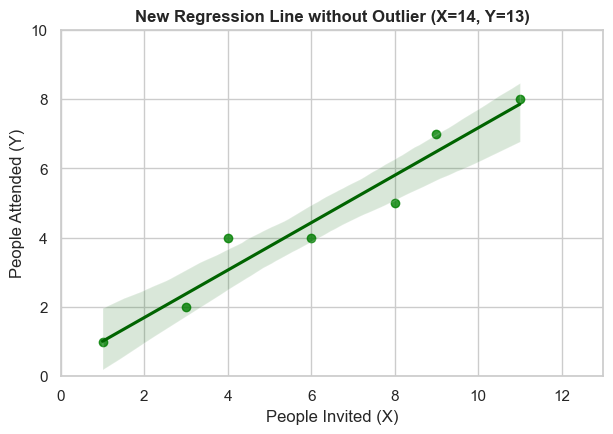

In [18]:
# Your response here.ok
# clean outlier & reclac
df_clean = df[df['X'] != 14]

X_clean = sm.add_constant(df_clean['X'])
model_clean = sm.OLS(df_clean['Y'], X_clean).fit()
print(model_clean.summary())

### graph
plt.figure(figsize=(7, 4.5))
sns.regplot(x='X', y='Y', data=df_clean, color='green', line_kws={'color': 'darkgreen'})
plt.title("New Regression Line without Outlier (X=14, Y=13)", fontweight='bold')
plt.xlabel("People Invited (X)")
plt.ylabel("People Attended (Y)")
plt.xlim(0, 13); plt.ylim(0, 10); plt.grid(True)
plt.show()

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

##### What changed?
- Model Fit ($R^2$): 
The $R^2$ increased slightly from 0.932 to 0.943, showing that both linear models are highly effective at describing the data.
- The Slope (X Coefficient): It dropped significantly from 0.855 to 0.686. This means that within the normal party range, for every 10 additional guests invited, only about 7 attend (and 3 flake), mathematically validating the host's hunch.

##### Form of the Data (With and Without the Outlier)
- With the point $(14, 13)$: 
The data hints at a slight curved or upward exponential shape at the tail end. The linear model is forced to pull the line upwards to reach that final massive success, distorting the trend for mid-sized parties.
- Without the point $(14, 13)$: 
The shape of the data becomes strictly linear. The remaining points align almost perfectly with the new path, proving that the host's regular party attendance is highly predictable and that the last party was simply an isolated exception.